In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# Cargar datos
import os

# Ruta relativa
current_dir = os.getcwd()
data_path = os.path.join(current_dir, '..', 'data', 'raw', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = pd.read_csv(data_path)
print("📊 Dataset cargado correctamente")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

📊 Dataset cargado correctamente
Dimensiones: 7043 filas x 21 columnas


In [3]:
# Primer vistazo
print("=" * 60)
print("PRIMER VISTAZO AL DATASET")
print("=" * 60)

# Primeras filas
print("\n🔍 Primeras 5 filas:")
display(df.head())

# Información general
print("\n📋 Información del dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas descriptivas (numéricas):")
display(df.describe())

# Estadísticas descriptivas categóricas
print("\n🎯 Estadísticas descriptivas (categóricas):")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Valores únicos: {df[col].nunique()}")
    print(f"  Top 5: {df[col].value_counts().head().to_dict()}")

PRIMER VISTAZO AL DATASET

🔍 Primeras 5 filas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



📋 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 no

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



🎯 Estadísticas descriptivas (categóricas):

customerID:
  Valores únicos: 7043
  Top 5: {'7590-VHVEG': 1, '5575-GNVDE': 1, '3668-QPYBK': 1, '7795-CFOCW': 1, '9237-HQITU': 1}

gender:
  Valores únicos: 2
  Top 5: {'Male': 3555, 'Female': 3488}

Partner:
  Valores únicos: 2
  Top 5: {'No': 3641, 'Yes': 3402}

Dependents:
  Valores únicos: 2
  Top 5: {'No': 4933, 'Yes': 2110}

PhoneService:
  Valores únicos: 2
  Top 5: {'Yes': 6361, 'No': 682}

MultipleLines:
  Valores únicos: 3
  Top 5: {'No': 3390, 'Yes': 2971, 'No phone service': 682}

InternetService:
  Valores únicos: 3
  Top 5: {'Fiber optic': 3096, 'DSL': 2421, 'No': 1526}

OnlineSecurity:
  Valores únicos: 3
  Top 5: {'No': 3498, 'Yes': 2019, 'No internet service': 1526}

OnlineBackup:
  Valores únicos: 3
  Top 5: {'No': 3088, 'Yes': 2429, 'No internet service': 1526}

DeviceProtection:
  Valores únicos: 3
  Top 5: {'No': 3095, 'Yes': 2422, 'No internet service': 1526}

TechSupport:
  Valores únicos: 3
  Top 5: {'No': 3473, 'Yes'

In [4]:
# Análisis de valores nulos
print("=" * 60)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 60)

null_counts = df.isnull().sum()
null_percentage = (null_counts / len(df)) * 100

null_df = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje': null_percentage
}).sort_values('Porcentaje', ascending=False)

null_df = null_df[null_df['Valores Nulos'] > 0]

if len(null_df) > 0:
    display(null_df)
else:
    print("✅ No hay valores nulos en el dataset")
    
# Verificar espacios en blanco como "nulos"
print("\n🔍 Verificando espacios en blanco...")
for col in df.columns:
    if df[col].dtype == 'object':
        blancos = df[col].str.strip().eq('').sum()
        if blancos > 0:
            print(f"  {col}: {blancos} valores en blanco")

ANÁLISIS DE VALORES NULOS
✅ No hay valores nulos en el dataset

🔍 Verificando espacios en blanco...


ANÁLISIS DE LA VARIABLE TARGET: Churn

📊 Distribución de Churn:


,Count,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


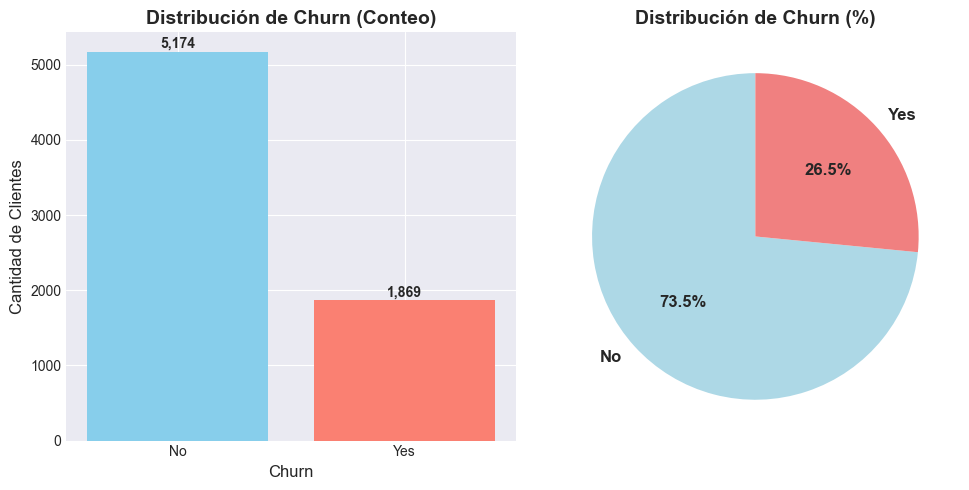


💡 Insight: El dataset está desbalanceado. Solo el 26.5% de los clientes hicieron churn.
Esto es importante para el modelado (posible necesidad de balanceo de clases).


In [5]:
# Análisis de la variable target
print("=" * 60)
print("ANÁLISIS DE LA VARIABLE TARGET: Churn")
print("=" * 60)

# Distribución
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

churn_df = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percentage
})

print("\n📊 Distribución de Churn:")
display(churn_df)

# Visualización
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(churn_counts.index, churn_counts.values, color=['skyblue', 'salmon'])
plt.title('Distribución de Churn (Conteo)', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Agregar valores encima de las barras
for bar, count in zip(bars, churn_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}', ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['lightblue', 'lightcoral'], startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Distribución de Churn (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: El dataset está desbalanceado. Solo el {churn_percentage['Yes']:.1f}% de los clientes hicieron churn.")
print("Esto es importante para el modelado (posible necesidad de balanceo de clases).")